---
title: Inference regimes
---


In [12]:
import tspaint
import msprime, demesdraw
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme(style='ticks')
from tspaint.sim import SOURCE_A, ADMIXED, ANCESTRAL, SOURCE_B, REF_A_PROXY, REF_B_PROXY, A_ANCESTRAL, B_ANCESTRAL

WORK = tempfile.mkdtemp(prefix="tspaint_showcase_")

def pops(ts):
    '''sample-node -> source name, and a {name: pop_id} lookup.'''
    npop = ts.tables.nodes.population
    name = {p: ts.population(p).metadata.get("name", str(p)) for p in range(ts.num_populations)}
    pid = {n: p for p, n in name.items()}
    samples_of = lambda nm: [int(s) for s in ts.samples() if npop[s] == pid[nm]]
    return name, pid, samples_of


def write_vcz(ts, path):
    '''Write a minimal VCF-Zarr (vcz) store from a mutated ts (stand-in for vcf2zarr output).'''
    import zarr
    G = ts.genotype_matrix()                       # (sites, samples), biallelic 0/1
    V, N = G.shape
    root = zarr.open(path, mode="w")
    def arr(nm, data, dims):
        root[nm] = data
        root[nm].attrs["_ARRAY_DIMENSIONS"] = dims
    arr("variant_position", np.asarray(ts.tables.sites.position).astype("i8"), ["variants"])
    arr("call_genotype", G[:, :, None].astype("i1"), ["variants", "samples", "ploidy"])
    arr("variant_allele", np.array([["0", "1"]] * V), ["variants", "alleles"])
    arr("variant_contig", np.zeros(V, "i4"), ["variants"])
    arr("contig_id", np.array(["1"]), ["contigs"])
    arr("sample_id", np.array([f"n{i}" for i in range(N)]), ["samples"])
    arr("variant_ancestral_allele", np.array(["0"] * V), ["variants"])
    return path

tubes_kwargs=dict(
    colours=dict(zip([SOURCE_A, ADMIXED, ANCESTRAL, SOURCE_B], list(sns.color_palette().as_hex()))),
    log_time=True
)
sequence_length = 2e6
ploidy = 2
recombination_rate = 1e-8
mutation_rate = 1.2e-8
random_seed = 42

In [ ]:
n_admix = 8
n_ref = 8

Ne = 10_000
T_split = 150_000
T_split_A = 50_000
T_split_B = 30_000
T_admix = 500
f_A = 0.5


demography = tspaint.sim.admixture_demography()

ts_true = io.add_mutations(ts_true, rate=mutation_rate, random_seed=1)
name, pid, samples_of = pops(ts_true)
queries = samples_of("ADMIX")

# PROXY references: A_prox anchors state 0 (like A), B_prox state 1 (like B)
labels_proxy  = {s: 0 for s in samples_of(SOURCE_A + '_prox')}
labels_proxy.update({s: 1 for s in samples_of(SOURCE_B + '_prox')})

# DIRECT references (the usual head-to-head baseline)
labels_direct  = {s: 0 for s in samples_of(SOURCE_A)}
labels_direct.update({s: 1 for s in samples_of(SOURCE_B)})

print(f"{ts_true.num_samples} haplotypes, {ts_true.num_sites} sites; "
      f"{len(queries)} query haplotypes, {len(labels_proxy)} labelled references (A=0, B=1)")


demesdraw.tubes(msprime.Demography.to_demes(demography), **tubes_kwargs) ;

KeyError: "Population with name 'A_prox' not found"

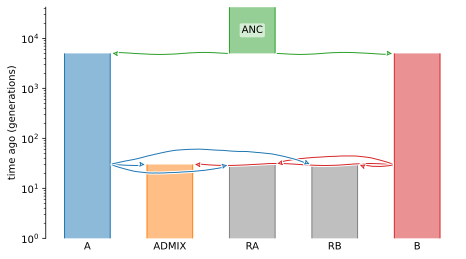

In [4]:
demography = tspaint.sim.admixture_demography_impure_refs()
demesdraw.tubes(msprime.Demography.to_demes(demography), **tubes_kwargs) ;

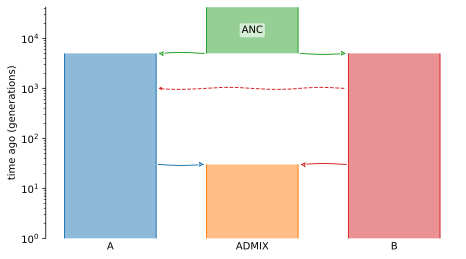

In [5]:
demography = tspaint.sim.admixture_demography_source_gene_flow()
demesdraw.tubes(msprime.Demography.to_demes(demography), **tubes_kwargs) ;

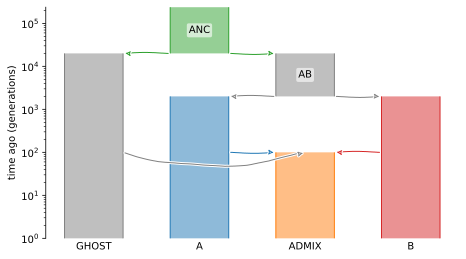

In [6]:
demography = tspaint.sim.admixture_demography_with_ghost()
demesdraw.tubes(msprime.Demography.to_demes(demography), **tubes_kwargs) ;

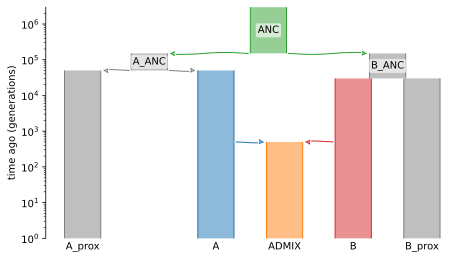

In [8]:
demography = tspaint.sim.admixture_demography_with_ref_proxies()
demesdraw.tubes(msprime.Demography.to_demes(demography), **tubes_kwargs) ;

## Clean references, no ILS

## ILS

## Impure references

### References with independent admixture

### References with past admixture from same population

## Reference proxies

## Mixing proxies and impure references

The two reference types are complementary:


|                           |   clean deep proxy (A_prox)   |    impure near-source (A)    |
|:---|:---|:---|
| coalescence with the      | deep (~T_CA) → weaker         | shallow → strong signal      |
| query's A-tract           | per-locus signal              |                              |
| contamination             | clean by construction         | carries foreign (B) tracts → wrong votes |
| role                      | contamination-immune anchor   | high-resolution, but noisy   |


Why combining them beats either alone

Label both state 0 (they jointly define the "A-side"). Then:
- Where the near-source is clean, the query coalesces shallowly with it → strong, correct
signal, and the proxy just reinforces.
- Where the near-source is contaminated (a B-tract in the A panel), it would vote "B" there —
but the clean proxy has no B-tract at that locus, so it backstops the A-side. The proxy rescues
exactly the loci where the near-source is wrong.
- Identifiability (§6). The proxy is the ideal trusted hard-anchor core — clean by construction,
a genuinely separate population. And that's what makes it safe to soften or fragment-mask the 
impure near-source: softening alone risks the "whole panel floats" degeneracy, but with the
proxy holding the A-side fixed, you can aggressively down-weight/mask the contaminated
near-source without collapse.

So it's the §6 design — hard-clamped trusted core + softened suspects — with the proxy supplying
a core you can actually trust.

It fixes the exact regime that failed

Recall the measured source-gene-flow result: all A-refs ~10 % B, no pure A core → soft-w and
fragment-mask gave nothing or slightly worse, and the diagnosis was precisely "no clean anchor
to fall back on." A deep proxy is that missing clean anchor. So proxy +
softened-impure-near-source should help right where impure-alone failed — that's the concrete,
testable prediction.

There's likely a second-order bonus too: the deep proxy discriminates at the deep level, which
(per the earlier §9 discussion) tends to survive older admixture better than the shallow
query↔near-source link. So the pair gives you strong resolution recently (near-source) and a
deep backstop that reaches further back (proxy).

The recipe (already supported — no new code)

labels = {s: 0 for s in samples_of("A_prox") + samples_of("A")}
labels.update({s: 1 for s in samples_of("B_prox") + samples_of("B")})

# proxy = clean anchor core; impure near-source softened (or masked)
qc = tspaint.reference_qc(ts, labels, anchors=set(samples_of("A_prox") + samples_of("B_prox")))
painting = tspaint.paint(ts, labels, queries=queries, soft_refs=qc.soft_refs())   # or 
mask=qc.mask()
reference_qc would auto-select the proxy as the anchor anyway (it's the most self-consistent),
but passing anchors= the proxies is the robust, explicit choice.

Caveats

- Don't just hard-clamp the impure near-source alongside the proxy — its contamination still
votes wrong (the proxy only dilutes it). The benefit needs the near-source softened/masked, with
the proxy as the anchor that makes that safe.
- The proxy must be a good proxy (close sister, long internal branch). A poor proxy (T_CA ≈
T_root) adds little and can dilute.
- Mixing shallow + deep references on one side is fine for the model — both are state 0, so
intra-A-side coalescences carry no A↔B transition; the adaptive Q0 handles the timescale.

This is worth measuring directly, and it's a small extension of what you're already building:
take the source-gene-flow sim (impure A/B, the case that failed), add A_prox/B_prox, and compare
proxy-only vs impure-only(soft/mask) vs proxy + impure(soft/mask). My prediction is the
combination wins — proxy restores the anchor, near-source restores the resolution. Want me to
wire that arm into the impure-reference experiment?